<a href="https://colab.research.google.com/github/MichelleLea26/KnowledgeGraph-Wikidata/blob/main/Analisis_Sentralitas_Films.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deskripsi

Proyek ini bertujuan untuk memetakan hubungan antara Studio Produksi, Karya Film, dan Platform Distribusi (Streaming) menggunakan data dari Knowledge Graph global (Wikidata/DBpedia). Melalui pendekatan Network Science, kita akan melihat bagaimana ekosistem film terbentuk di era digital.

# Penggabungan Data (Data Joining)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load Data CSV
df_wiki = pd.read_csv('wikidata_film.csv')
df_dbpedia = pd.read_csv('dbpedia_film.csv')

In [ ]:
# Normalisasi Match Key
df_wiki['match_key'] = df_wiki['Movie'].astype(str).str.lower().str.strip()
df_dbpedia['match_key'] = df_dbpedia['Movie'].astype(str).str.lower().str.strip()

In [ ]:
# Mengelompokan duplikasi
df_dbpedia_grouped = df_dbpedia.groupby('match_key').agg({
    'wiki_url': 'first',
    'Genre': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'Director': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'Year': 'first', # Ambil tahun pertama saja
    'Studio_DBpedia': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'Platform_DBpedia': lambda x: ', '.join(x.dropna().astype(str).unique())
}).reset_index()

In [ ]:
# Integrasi
df_final = pd.merge(df_wiki, df_dbpedia_grouped, on='match_key', how='left')

In [ ]:
# Melengkapi Data
df_final['Studio'] = df_final['Studio'].fillna(df_final['Studio_DBpedia'])
df_final.loc[df_final['Studio'] == '', 'Studio'] = df_final['Studio_DBpedia']

In [ ]:
# Pembersihan Akhir
df_final = df_final.drop(columns=['match_key', 'Studio_DBpedia', 'Platform_DBpedia'])

df_final = df_final.replace(r'^\s*$', np.nan, regex=True)

In [ ]:
# Simpan CSV
df_final.to_csv('dataset_terintegrasi_films.csv', index=False)
print("Data berhasil diintegrasikan! Berikut rinciannya:")
print(df_final.info())

Data berhasil diintegrasikan! Berikut rinciannya:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Movie     2000 non-null   object
 1   Studio    2000 non-null   object
 2   Platform  1350 non-null   object
 3   imdb_id   2000 non-null   object
 4   wiki_url  6 non-null      object
 5   Genre     2 non-null      object
 6   Director  6 non-null      object
 7   Year      2 non-null      object
dtypes: object(8)
memory usage: 125.1+ KB
None


# Analisis Graf (Network Analysis)

Membangun Graph dari df_final...
Graph berhasil dibuat! Jumlah Node: 1732, Jumlah Edge: 2487
Menghitung skor PageRank...

--- TOP 10 ENTITAS DENGAN PAGERANK TERTINGGI ---
                                Entity  PageRank
0           Warner Bros. Entertainment  0.057185
1                                  UFA  0.046223
2                              Netflix  0.043199
3                              Mosfilm  0.022325
4                 Georgian Film Studio  0.022057
5                             Shochiku  0.019280
6              The Walt Disney Company  0.015294
7                                 Arte  0.014696
8            Triangle Film Corporation  0.012796
9  Walt Disney Studios Motion Pictures  0.012471


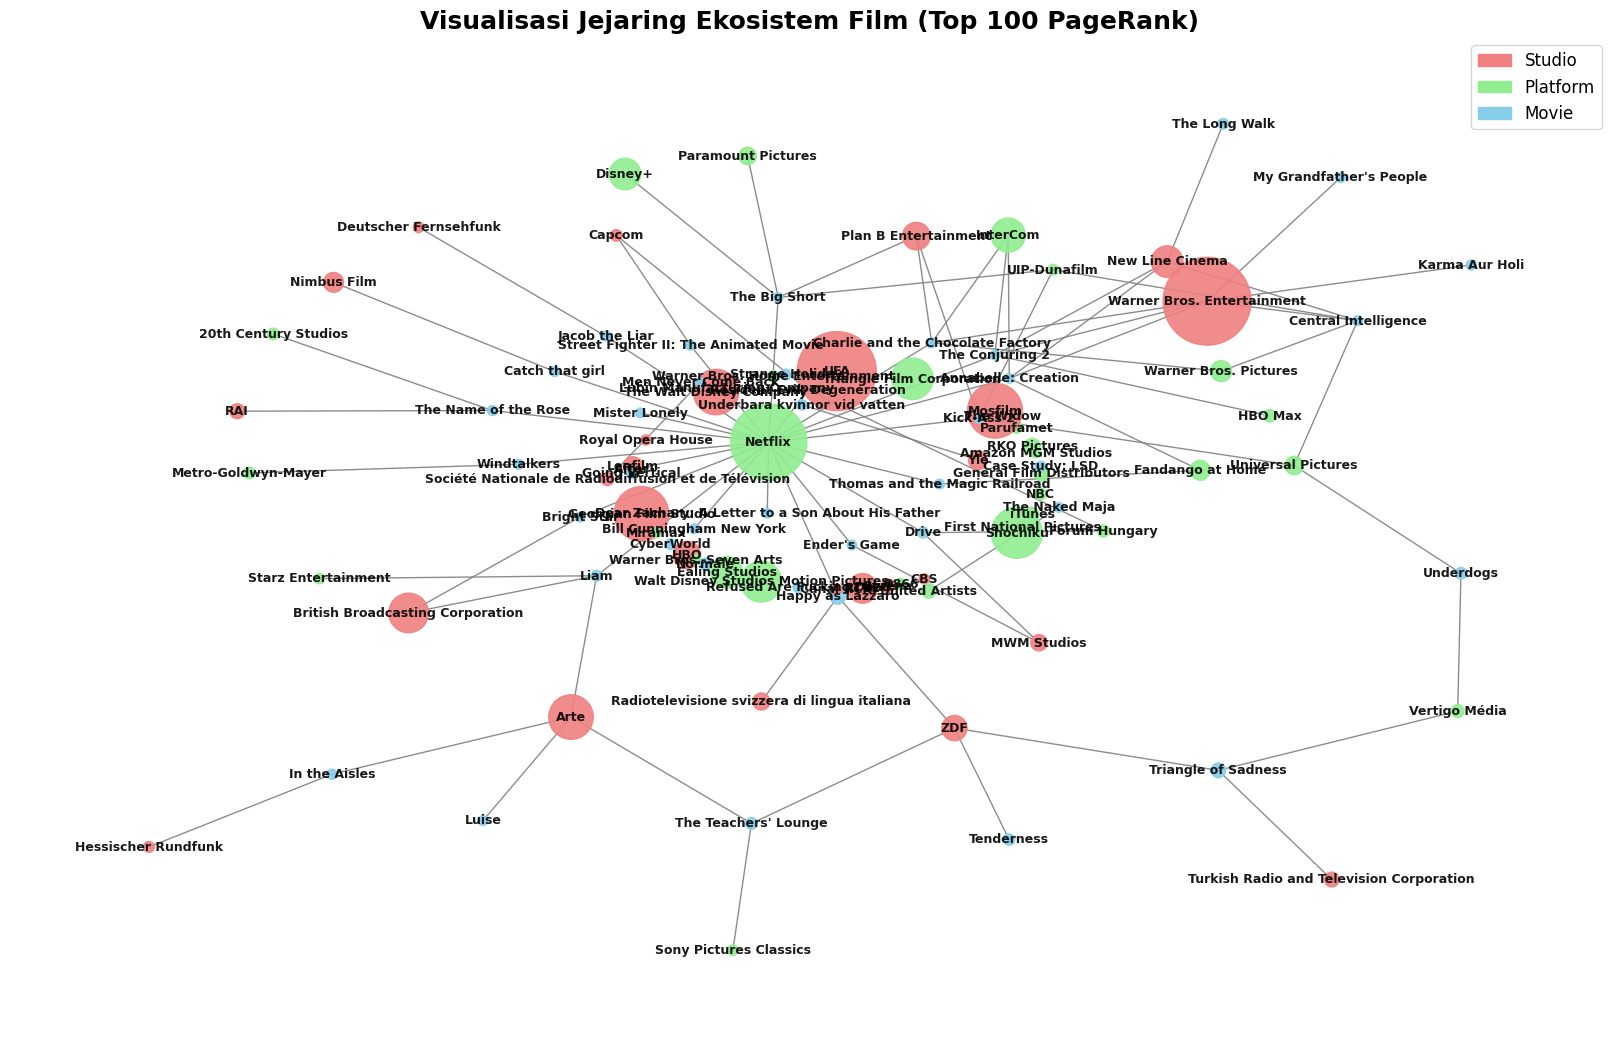

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

# --- 1. MEMBANGUN GRAPH ---
print("Membangun Graph dari df_final...")
G = nx.Graph()

# Looping data untuk membuat Edge (Garis Hubungan)
for index, row in df_final.iterrows():
    movie = str(row['Movie'])
    studio = str(row['Studio'])

    # Tambahkan relasi Studio <--> Movie
    if pd.notna(row['Studio']) and pd.notna(row['Movie']):
        G.add_edge(studio, movie)
        # Tambahkan atribut tipe node agar mudah diwarnai nanti
        G.nodes[studio]['type'] = 'Studio'
        G.nodes[movie]['type'] = 'Movie'

    # Tambahkan relasi Movie <--> Platform (Cek jika platform tidak kosong/NaN)
    if pd.notna(row['Platform']):
        platform = str(row['Platform'])
        G.add_edge(movie, platform)
        G.nodes[platform]['type'] = 'Platform'

print(f"Graph berhasil dibuat! Jumlah Node: {G.number_of_nodes()}, Jumlah Edge: {G.number_of_edges()}")

# --- 2. MENGHITUNG PAGERANK ---
print("Menghitung skor PageRank...")
pagerank_scores = nx.pagerank(G)

# Masukkan hasil ke DataFrame agar rapi
pr_df = pd.DataFrame(list(pagerank_scores.items()), columns=['Entity', 'PageRank'])
pr_df = pr_df.sort_values(by='PageRank', ascending=False).reset_index(drop=True)

print("\n--- TOP 10 ENTITAS DENGAN PAGERANK TERTINGGI ---")
print(pr_df.head(10))

# --- 3. VISUALISASI GRAPH ---
# Karena datanya besar (2000+ node), kita visualisasikan Top 50 saja agar tidak jadi "Hairball" (Benang Kusut)
top_n = 100
top_nodes = pr_df['Entity'].head(top_n).tolist()

# Buat Sub-graph yang hanya berisi 50 entitas terpenting
sub_G = G.subgraph(top_nodes)

# Siapkan warna berdasarkan tipe entitas
color_map = []
for node in sub_G:
    node_type = sub_G.nodes[node].get('type', 'Unknown')
    if node_type == 'Studio':
        color_map.append('lightcoral')   # Merah Muda untuk Studio
    elif node_type == 'Platform':
        color_map.append('lightgreen')   # Hijau untuk Platform
    else:
        color_map.append('skyblue')      # Biru untuk Movie

# Atur ukuran node berdasarkan skor PageRank (dikali angka besar agar terlihat)
node_sizes = [pagerank_scores[node] * 70000 for node in sub_G]

# Mulai menggambar
plt.figure(figsize=(16, 10))
# Spring layout mengatur posisi agar node yang berhubungan saling tarik-menarik
pos = nx.kamada_kawai_layout(sub_G)

nx.draw(sub_G, pos,
        with_labels=True,
        node_size=node_sizes,
        node_color=color_map,
        font_size=9,
        font_weight='bold',
        edge_color='gray',
        alpha=0.9)

# Buat Legenda Warna
studio_patch = mpatches.Patch(color='lightcoral', label='Studio')
platform_patch = mpatches.Patch(color='lightgreen', label='Platform')
movie_patch = mpatches.Patch(color='skyblue', label='Movie')
plt.legend(handles=[studio_patch, platform_patch, movie_patch], loc='upper right', fontsize=12)

plt.title(f"Visualisasi Jejaring Ekosistem Film (Top {top_n} PageRank)", fontsize=18, fontweight='bold')
plt.show()

Menyiapkan visualisasi yang rapi...


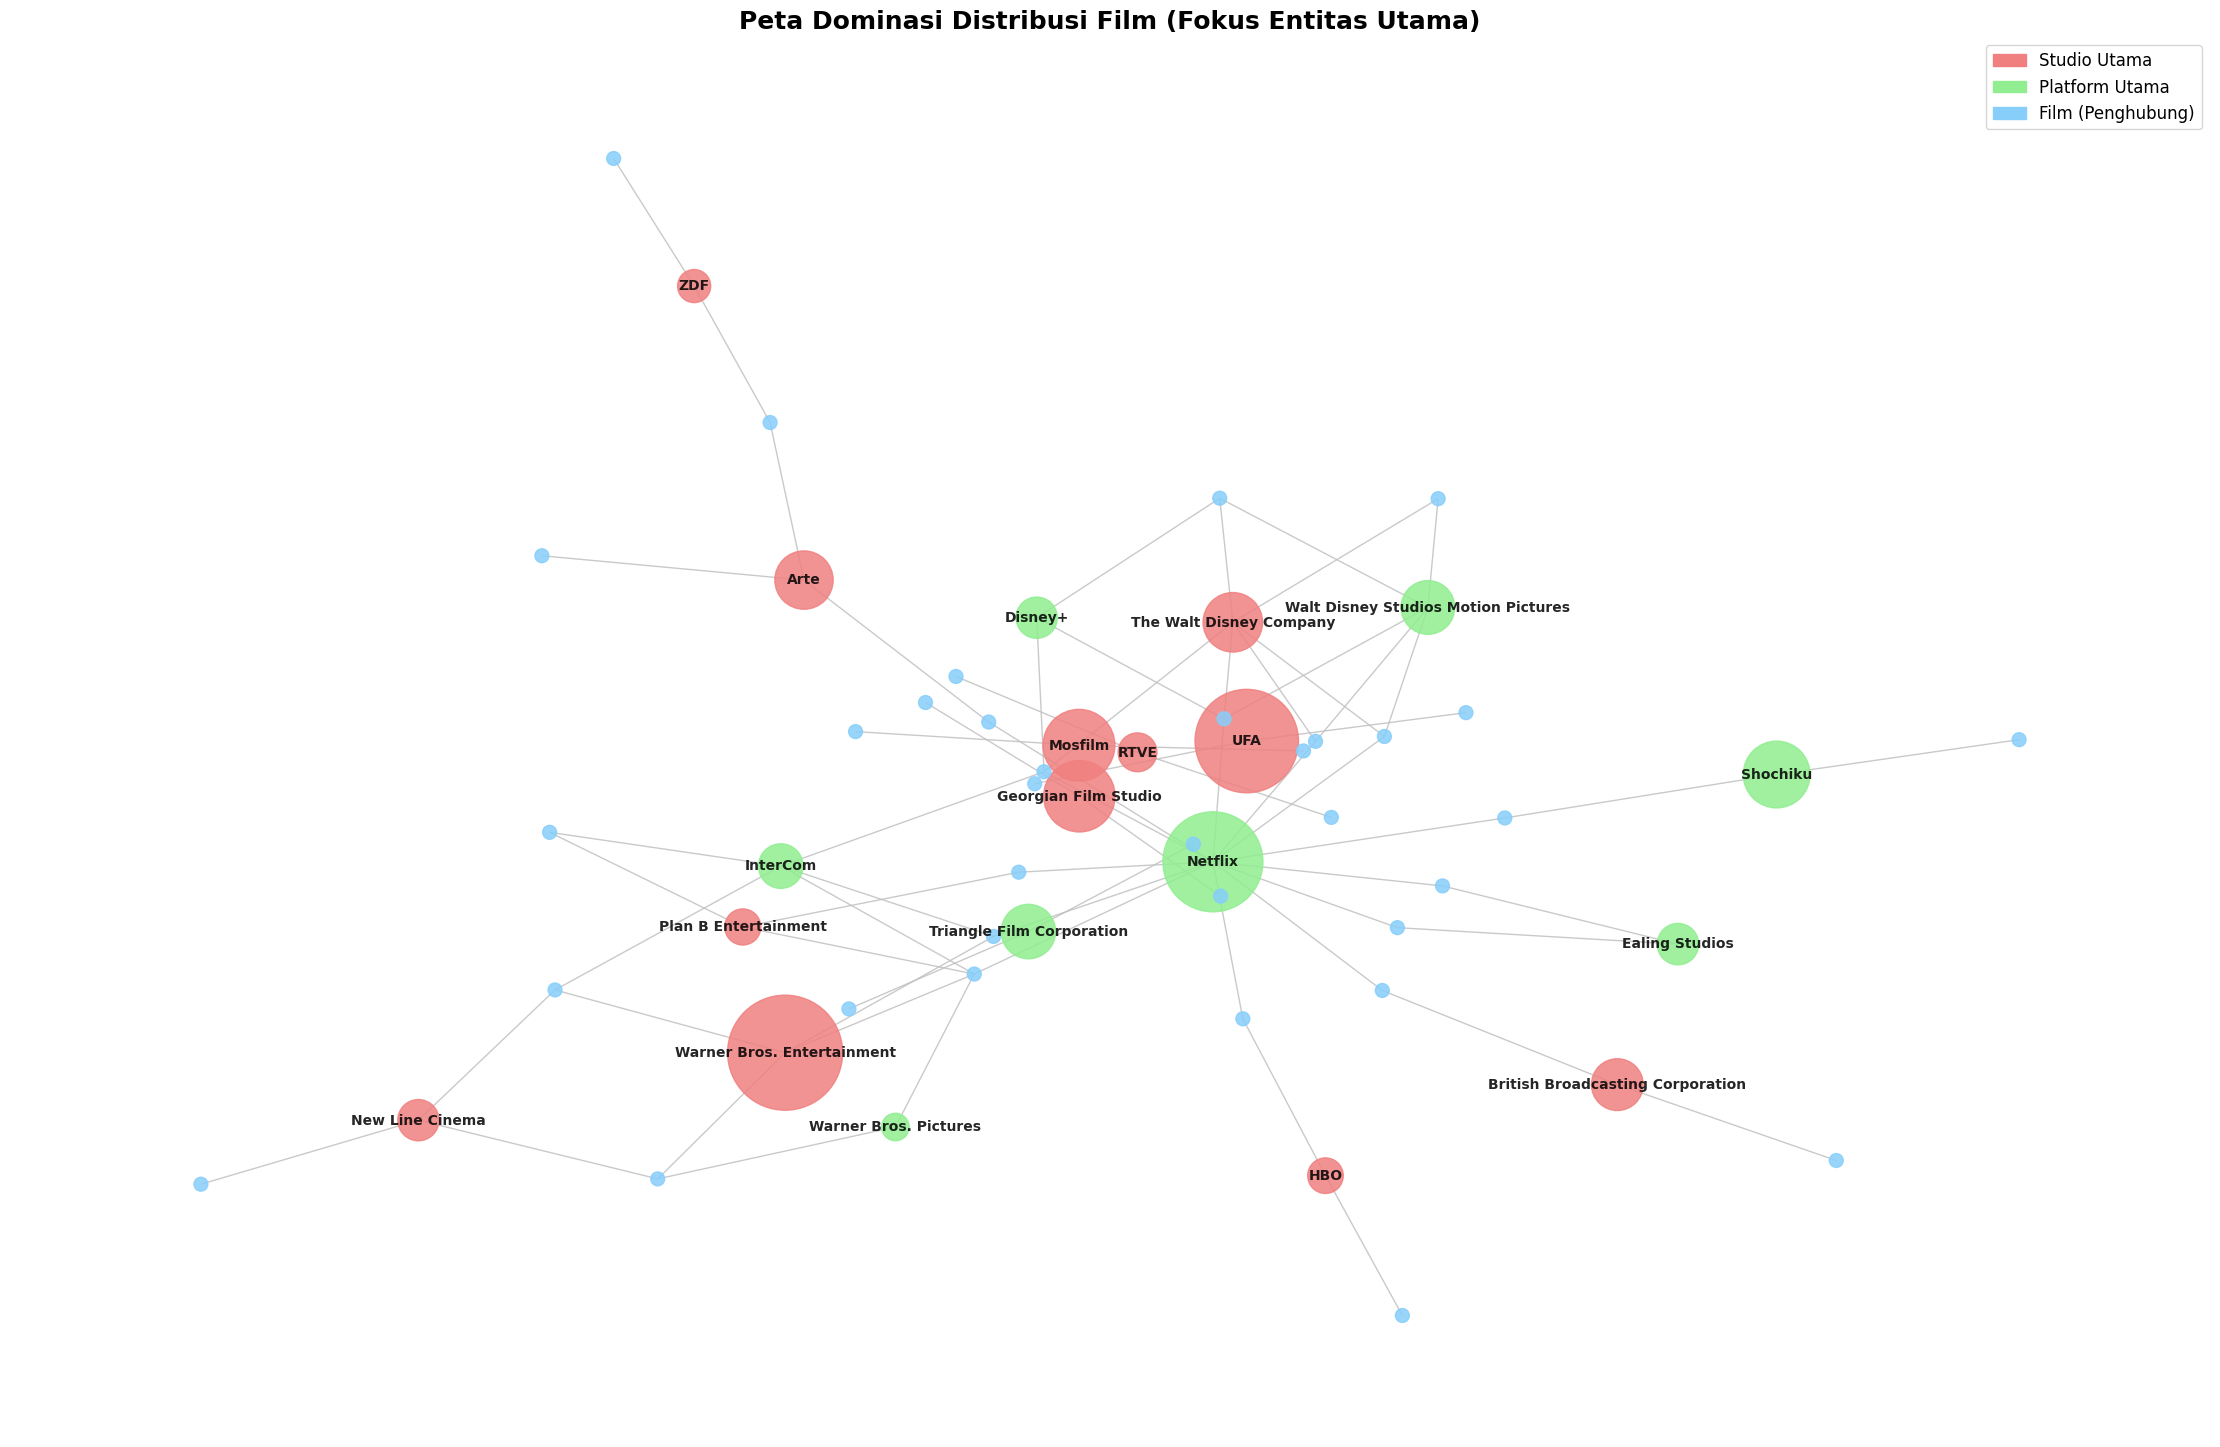

In [ ]:
# --- 3. VISUALISASI GRAPH (FOKUS KE RAKSASA) ---
print("Menyiapkan visualisasi yang rapi...")

# 1. Ambil Top 20 Entitas Utama (Raksasa)
top_20_hubs = pr_df['Entity'].head(20).tolist()
nodes_to_draw = set(top_20_hubs)

# 2. Cari "Jembatan" (Film)
for node in top_20_hubs:
    if G.has_node(node):
        neighbors = list(G.neighbors(node))
        # KURANGI: Ambil maksimal 2 film saja per entitas agar tidak semrawut
        nodes_to_draw.update(neighbors[:2])

sub_G = G.subgraph(nodes_to_draw)

# 3. Siapkan Atribut (Warna, Ukuran, dan Label)
color_map = []
node_sizes = []
custom_labels = {} # Dictionary untuk mengatur teks mana yang muncul

for node in sub_G:
    node_type = sub_G.nodes[node].get('type', 'Unknown')

    # Atur Warna
    if node_type == 'Studio':
        color_map.append('lightcoral')
    elif node_type == 'Platform':
        color_map.append('lightgreen')
    else:
        color_map.append('lightskyblue')

    # Atur Ukuran & Label
    if node in top_20_hubs:
        node_sizes.append(pagerank_scores[node] * 120000) # Raksasa diperbesar
        custom_labels[node] = node                        # Tampilkan teks namanya
    else:
        node_sizes.append(100)  # Film dikecilkan jadi titik saja
        custom_labels[node] = "" # Kosongkan teks/nama filmnya

# 4. Mulai menggambar
plt.figure(figsize=(22, 14))
pos = nx.kamada_kawai_layout(sub_G)

# Gambar Jaringannya
nx.draw(sub_G, pos,
        labels=custom_labels,      # Gunakan label custom (film tidak ada teksnya)
        with_labels=True,
        node_size=node_sizes,
        node_color=color_map,
        font_size=10,
        font_weight='bold',
        edge_color='silver',       # Warna garis dilembutkan
        alpha=0.85)

# Buat Legenda
studio_patch = mpatches.Patch(color='lightcoral', label='Studio Utama')
platform_patch = mpatches.Patch(color='lightgreen', label='Platform Utama')
movie_patch = mpatches.Patch(color='lightskyblue', label='Film (Penghubung)')
plt.legend(handles=[studio_patch, platform_patch, movie_patch], loc='upper right', fontsize=12)

plt.title("Peta Dominasi Distribusi Film (Fokus Entitas Utama)", fontsize=18, fontweight='bold')
plt.show()